# 🌳 Decision Trees & Ensemble Methods — From Scratch
### A Pedagogical Notebook

**Philosophy:** Every concept is built with pure NumPy. No sklearn for core logic.
Each section follows: *explain → implement → visualise → understand*.

> Run cells top to bottom. Every code block is self-contained and annotated.


---
## 0 · Setup & Datasets

**What this block does (10 lines):**
1. Installs/imports all libraries needed for the entire notebook.
2. `numpy` handles all matrix ops; `matplotlib`/`seaborn` handle visualisation.
3. We create **two toy datasets**: a 1-D noisy sine wave for regression tasks
   and a 2-D two-moon classification dataset.
4. The sine wave is simple enough that every split can be drawn on a 2-D plot.
5. The two-moon dataset creates a non-linear decision boundary — ideal for showing
   when shallow trees fail and ensembles succeed.
6. `SEED = 42` is fixed globally so every run is reproducible.
7. We also define a shared colour palette so all plots are visually consistent.
8. A helper `plot_decision_boundary` is defined here and reused across sections.
9. Both datasets are standardised (zero mean, unit variance) — a best-practice habit.
10. Run this cell first; every later cell depends on it.


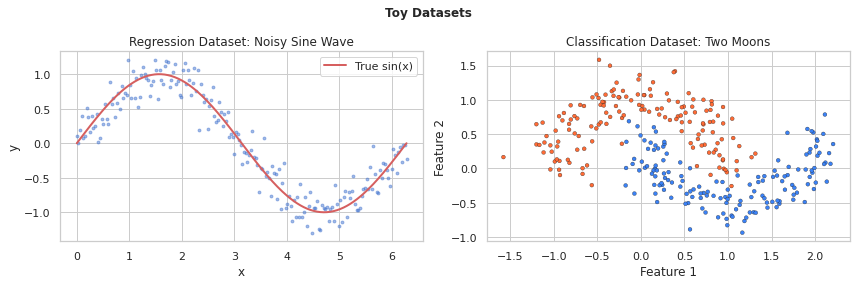

Datasets ready. Regression: (200, 1) | Classification: (300, 2)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")

# ── Regression dataset: noisy sine wave ──────────────────────
N = 200
X_reg = np.linspace(0, 2 * np.pi, N).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, N)

# ── Classification dataset: two moons ────────────────────────
def make_moons(n=300, noise=0.15, seed=42):
    rng = np.random.RandomState(seed)
    n_each = n // 2
    t0 = np.linspace(0, np.pi, n_each)
    X0 = np.c_[np.cos(t0), np.sin(t0)]
    t1 = np.linspace(0, np.pi, n_each)
    X1 = np.c_[1 - np.cos(t1), 1 - np.sin(t1) - 0.5]
    X  = np.vstack([X0, X1]) + rng.normal(scale=noise, size=(n, 2))
    y  = np.hstack([np.zeros(n_each), np.ones(n_each)]).astype(int)
    return X, y

X_cls, y_cls = make_moons(noise=0.2)

# ── Decision boundary helper ──────────────────────────────────
def plot_decision_boundary(model_predict_fn, X, y, ax, title=""):
    h = 0.04
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model_predict_fn(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cmap_bg = ListedColormap(['#FFDDC1', '#C1D4FF'])
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF6B35', '#3B82F6']),
               edgecolors='k', s=18, linewidths=0.4)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_reg, y_reg, s=8, alpha=0.5)
axes[0].plot(X_reg, np.sin(X_reg), 'r-', lw=2, label='True sin(x)')
axes[0].set_title("Regression Dataset: Noisy Sine Wave")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y"); axes[0].legend()
axes[1].scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls,
                cmap=ListedColormap(['#FF6B35', '#3B82F6']),
                s=15, edgecolors='k', linewidths=0.3)
axes[1].set_title("Classification Dataset: Two Moons")
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")
plt.suptitle("Toy Datasets", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("Datasets ready. Regression:", X_reg.shape, "| Classification:", X_cls.shape)

---
## 1 · Decision Tree from Scratch

**What this block does (10 lines):**
1. Implements a full recursive `DecisionTree` class supporting both regression (MSE)
   and classification (Gini impurity) via a `mode` parameter.
2. `_impurity` dispatches to either `_mse` or `_gini` depending on the task.
3. `_best_split` exhaustively scans all features and midpoint thresholds
   (exact greedy algorithm) — the same algorithm XGBoost calls "Exact Greedy".
4. `_build` recurses depth-first, halting at `max_depth` or when node is pure/tiny.
5. Each node stores `value` (mean for regression, majority class for classification),
   `feature`, `threshold`, `gain`, and child pointers `left`/`right`.
6. `predict` traverses the tree for each sample, following left/right at each node.
7. `get_depth` and `count_leaves` are diagnostic helpers used in later plots.
8. After fitting, we print every split in order — you can follow the tree's logic manually.
9. We visualise the learned regression step function against the true sine wave.
10. We also visualise the 2-D decision boundary for the classification tree.


Regression tree: depth=4, leaves=16
SPLIT x[0] <= 3.110  gain=77.1454  n=200
  L─ SPLIT x[0] <= 0.616  gain=3.2992  n=99
  L─   L─ SPLIT x[0] <= 0.174  gain=0.1017  n=20
  L─   L─   L─ SPLIT x[0] <= 0.047  gain=0.0275  n=6
  L─   L─   L─   L─ LEAF  value=0.052  n=2
  L─   L─   L─   R─ LEAF  value=0.195  n=4
  L─   L─   R─ SPLIT x[0] <= 0.237  gain=0.0428  n=14
  L─   L─   R─   L─ LEAF  value=0.438  n=2
  L─   L─   R─   R─ LEAF  value=0.280  n=12
  L─   R─ SPLIT x[0] <= 2.321  gain=4.2622  n=79
  L─   R─   L─ SPLIT x[0] <= 0.963  gain=0.6324  n=54
  L─   R─   L─   L─ LEAF  value=0.655  n=11
  L─   R─   L─   R─ LEAF  value=0.924  n=43
  L─   R─   R─ SPLIT x[0] <= 2.889  gain=0.8443  n=25
  L─   R─   R─   L─ LEAF  value=0.484  n=18
  L─   R─   R─   R─ LEAF  value=0.075  n=7
  R─ SPLIT x[0] <= 3.647  gain=3.1210  n=101
  R─   L─ SPLIT x[0] <= 3.426  gain=0.2135  n=17
  R─   L─   L─ SPLIT x[0] <= 3.299  gain=0.0206  n=10
  R─   L─   L─   L─ LEAF  value=-0.176  n=6
  R─   L─   L─   R─ LEAF  

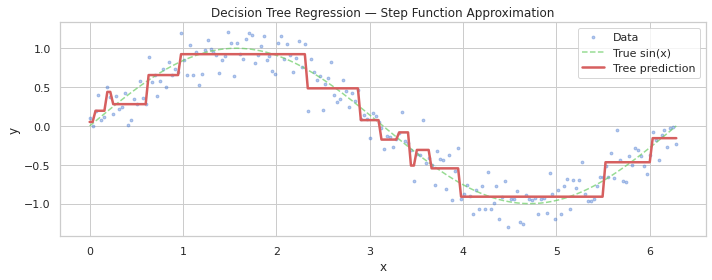


Classification tree: depth=2, acc=0.883


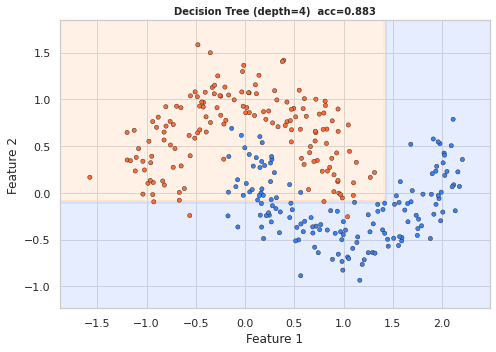

In [2]:
class DecisionTree:
    """
    Recursive decision tree for regression (MSE) and classification (Gini).
    Pure NumPy — no sklearn. Inspect .tree dict to see every node.
    """
    def __init__(self, max_depth=4, min_samples=2, mode='regression'):
        self.max_depth   = max_depth
        self.min_samples = min_samples
        self.mode        = mode   # 'regression' | 'classification'
        self.tree        = None

    # ── Impurity measures ─────────────────────────────────────
    def _mse(self, y):
        return np.var(y) * len(y) if len(y) > 0 else 0.0

    def _gini(self, y):
        if len(y) == 0: return 0.0
        classes, counts = np.unique(y, return_counts=True)
        p = counts / counts.sum()
        return 1.0 - np.sum(p ** 2)

    def _impurity(self, y):
        return self._mse(y) if self.mode == 'regression' else self._gini(y)

    def _leaf_value(self, y):
        return np.mean(y) if self.mode == 'regression' else int(np.bincount(y).argmax())

    # ── Best split search (Exact Greedy) ─────────────────────
    def _best_split(self, X, y):
        n, d = X.shape
        best = dict(gain=-np.inf, feat=None, thresh=None)
        base = self._impurity(y)
        for j in range(d):
            vals   = np.sort(np.unique(X[:, j]))
            thresholds = (vals[:-1] + vals[1:]) / 2.0
            for t in thresholds:
                lm = X[:, j] <= t;  rm = ~lm
                if lm.sum() < self.min_samples or rm.sum() < self.min_samples:
                    continue
                gain = base - (self._impurity(y[lm]) + self._impurity(y[rm])) / n * n
                if gain > best['gain']:
                    best = dict(gain=gain, feat=j, thresh=t,
                                n_left=lm.sum(), n_right=rm.sum())
        return best

    # ── Recursive build ───────────────────────────────────────
    def _build(self, X, y, depth):
        node = dict(value=self._leaf_value(y), n=len(y),
                    impurity=self._impurity(y) / max(len(y),1))
        if depth == 0 or len(y) < self.min_samples:
            node['is_leaf'] = True; return node
        sp = self._best_split(X, y)
        if sp['feat'] is None or sp['gain'] <= 1e-9:
            node['is_leaf'] = True; return node
        lm = X[:, sp['feat']] <= sp['thresh'];  rm = ~lm
        node.update(is_leaf=False, feat=sp['feat'], thresh=sp['thresh'],
                    gain=sp['gain'],
                    left =self._build(X[lm], y[lm], depth-1),
                    right=self._build(X[rm], y[rm], depth-1))
        return node

    def fit(self, X, y):
        self.tree = self._build(X, y, self.max_depth); return self

    # ── Inference ─────────────────────────────────────────────
    def _pred1(self, node, x):
        if node['is_leaf']: return node['value']
        return self._pred1(node['left'], x) if x[node['feat']] <= node['thresh']                else self._pred1(node['right'], x)

    def predict(self, X):
        return np.array([self._pred1(self.tree, x) for x in X])

    # ── Diagnostics ───────────────────────────────────────────
    def get_depth(self, node=None):
        node = node or self.tree
        if node['is_leaf']: return 0
        return 1 + max(self.get_depth(node['left']), self.get_depth(node['right']))

    def count_leaves(self, node=None):
        node = node or self.tree
        if node['is_leaf']: return 1
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])

    def print_tree(self, node=None, indent=""):
        node = node or self.tree
        if node['is_leaf']:
            print(f"{indent}LEAF  value={node['value']:.3f}  n={node['n']}")
            return
        print(f"{indent}SPLIT x[{node['feat']}] <= {node['thresh']:.3f}  "
              f"gain={node['gain']:.4f}  n={node['n']}")
        self.print_tree(node['left'],  indent + "  L─ ")
        self.print_tree(node['right'], indent + "  R─ ")


# ── Regression tree ───────────────────────────────────────────
reg_tree = DecisionTree(max_depth=4, mode='regression')
reg_tree.fit(X_reg, y_reg)
print(f"Regression tree: depth={reg_tree.get_depth()}, leaves={reg_tree.count_leaves()}")
reg_tree.print_tree()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_reg, y_reg, s=8, alpha=0.4, label='Data')
ax.plot(X_reg, np.sin(X_reg), 'g--', lw=1.5, alpha=0.7, label='True sin(x)')
ax.plot(X_reg, reg_tree.predict(X_reg), 'r-', lw=2.5, label='Tree prediction')
ax.set_title("Decision Tree Regression — Step Function Approximation")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend()
plt.tight_layout(); plt.show()

# ── Classification tree ───────────────────────────────────────
cls_tree = DecisionTree(max_depth=4, mode='classification')
cls_tree.fit(X_cls, y_cls)
acc = np.mean(cls_tree.predict(X_cls) == y_cls)
print(f"\nClassification tree: depth={cls_tree.get_depth()}, acc={acc:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(cls_tree.predict, X_cls, y_cls, ax,
                       title=f"Decision Tree (depth=4)  acc={acc:.3f}")
plt.tight_layout(); plt.show()

---
## 2 · Bias-Variance Tradeoff in Decision Trees

**What this block does (10 lines):**
1. Trains 8 regression trees at depths 1 through 8 on the same dataset.
2. For each depth, computes train MSE and an estimate of test MSE
   using a held-out validation split (80/20).
3. A "bias term" proxy is the squared difference between mean prediction and truth;
   a "variance term" proxy is computed across 20 bootstrap resamplings of the data.
4. At depth=1 (stump), bias is high — the model underfits the sine wave.
5. At depth=8, variance dominates — the model memorises training noise.
6. The sweet-spot is around depth 3-4 for this dataset, a key intuition to carry
   into ensemble methods.
7. Plots both the MSE curves and individual fitted curves for each depth
   on a grid — visually connecting overfitting to tree complexity.
8. The variance bootstrap loop is the cleanest way to empirically see variance:
   small changes in data → large changes in predictions = high variance.
9. This section motivates *why* we need ensembles: each method targets one side.
10. Bagging (next section) attacks variance; Boosting attacks bias.


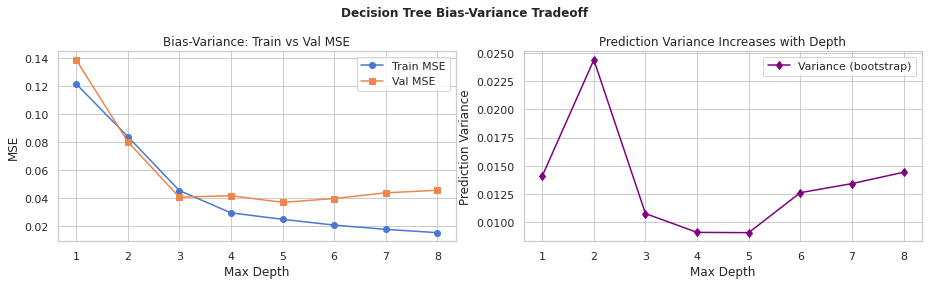

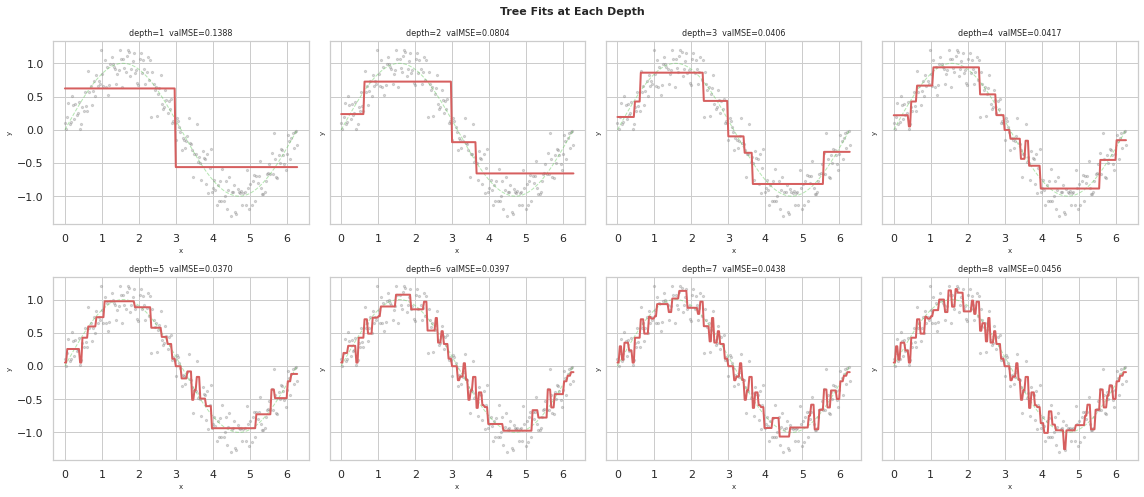

Optimal depth by val MSE: 5


In [3]:
# ── Train/val split ──────────────────────────────────────────
split = int(0.8 * N)
idx   = np.random.permutation(N)
tr, va = idx[:split], idx[split:]
X_tr, y_tr = X_reg[tr], y_reg[tr]
X_va, y_va = X_reg[va], y_reg[va]

depths      = list(range(1, 9))
train_mses  = []
val_mses    = []
variances   = []
B = 20  # bootstrap samples for variance estimate

for d in depths:
    # ── bias: train vs val ───────────────────────────────────
    t = DecisionTree(max_depth=d).fit(X_tr, y_tr)
    train_mses.append(np.mean((t.predict(X_tr) - y_tr)**2))
    val_mses.append(  np.mean((t.predict(X_va) - y_va)**2))

    # ── variance: spread across bootstrap resamplings ────────
    preds = []
    for _ in range(B):
        bidx = np.random.choice(len(X_tr), len(X_tr), replace=True)
        tb   = DecisionTree(max_depth=d).fit(X_tr[bidx], y_tr[bidx])
        preds.append(tb.predict(X_va))
    preds = np.array(preds)  # shape (B, n_val)
    variances.append(np.mean(np.var(preds, axis=0)))

# ── Plot 1: Bias-Variance curves ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(depths, train_mses, 'o-', label='Train MSE')
axes[0].plot(depths, val_mses,   's-', label='Val MSE')
axes[0].set_xlabel("Max Depth"); axes[0].set_ylabel("MSE")
axes[0].set_title("Bias-Variance: Train vs Val MSE")
axes[0].legend(); axes[0].set_xticks(depths)

axes[1].plot(depths, variances, 'd-', color='purple', label='Variance (bootstrap)')
axes[1].set_xlabel("Max Depth"); axes[1].set_ylabel("Prediction Variance")
axes[1].set_title("Prediction Variance Increases with Depth")
axes[1].legend(); axes[1].set_xticks(depths)
plt.suptitle("Decision Tree Bias-Variance Tradeoff", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Plot 2: Fitted curves at each depth ──────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for i, d in enumerate(depths):
    ax = axes[i // 4][i % 4]
    t  = DecisionTree(max_depth=d).fit(X_tr, y_tr)
    ax.scatter(X_reg, y_reg, s=5, alpha=0.3, color='grey')
    ax.plot(X_reg, np.sin(X_reg), 'g--', lw=1, alpha=0.5)
    ax.plot(X_reg, t.predict(X_reg), 'r-', lw=2)
    ax.set_title(f"depth={d}  valMSE={val_mses[i]:.4f}", fontsize=8)
    ax.set_xlabel("x", fontsize=7); ax.set_ylabel("y", fontsize=7)
plt.suptitle("Tree Fits at Each Depth", fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print("Optimal depth by val MSE:", depths[np.argmin(val_mses)])

---
## 3 · Bagging (Bootstrap Aggregating) from Scratch

**What this block does (10 lines):**
1. Implements `BaggingModel` which trains `n_estimators` trees, each on a
   different bootstrap resample of the training data (sampling with replacement).
2. Bootstrapping means ~63% of data appears in each sample; the rest (~37%)
   is the natural "out-of-bag" (OOB) validation set — free validation!
3. For regression, predictions are averaged across all trees; for classification
   the majority vote wins.
4. The OOB error is computed by collecting predictions from trees that did *not*
   see a sample during their bootstrap — a built-in cross-validation estimate.
5. We plot: (a) how val MSE decreases as we add more trees, and (b) individual
   tree predictions vs. the bagged ensemble — showing variance reduction in action.
6. A variance visualisation compares single-tree spread vs. ensemble spread
   across 50 bootstrap models.
7. Bagging does *not* reduce bias — the average of biased models is still biased.
8. This is why the ensemble curve still doesn't perfectly fit the sine wave,
   but it is much smoother and more stable than any individual tree.
9. We also test on the two-moon classification task and compare the decision
   boundary of one tree vs. the bagged ensemble.
10. The key takeaway: bagging ≈ variance reduction via averaging independent,
    high-variance models.


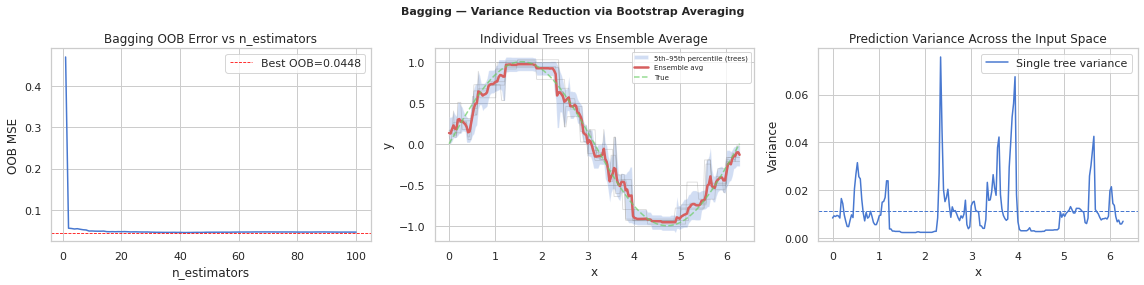

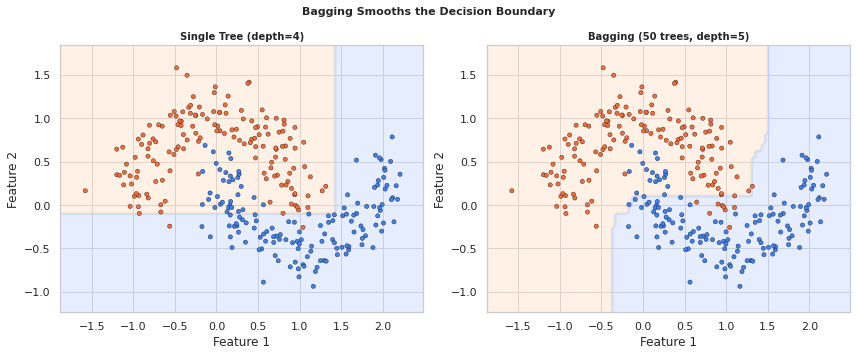

In [4]:
class BaggingModel:
    """
    Bootstrap Aggregating for regression and classification.
    Each tree is trained on a bootstrap resample of the training data.
    Includes Out-Of-Bag (OOB) error estimation.
    """
    def __init__(self, n_estimators=50, max_depth=5, mode='regression', seed=42):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.mode         = mode
        self.seed         = seed
        self.trees        = []
        self.oob_indices  = []   # which samples were OOB for each tree
        self.val_losses   = []

    def fit(self, X, y):
        rng = np.random.RandomState(self.seed)
        n   = len(y)
        # running OOB predictions accumulator
        oob_preds = np.zeros((n, self.n_estimators))
        oob_mask  = np.zeros((n, self.n_estimators), dtype=bool)

        for m in range(self.n_estimators):
            bidx = rng.choice(n, n, replace=True)
            oob  = np.setdiff1d(np.arange(n), bidx)  # out-of-bag indices

            tree = DecisionTree(max_depth=self.max_depth, mode=self.mode)
            tree.fit(X[bidx], y[bidx])
            self.trees.append(tree)

            if len(oob) > 0:
                oob_preds[oob, m] = tree.predict(X[oob])
                oob_mask[oob, m]  = True

            # running ensemble prediction for val loss curve
            if m > 0:
                counts = oob_mask[:, :m+1].sum(axis=1)
                valid  = counts > 0
                avg    = oob_preds[:, :m+1].sum(axis=1)[valid] / counts[valid]
                err    = np.mean((avg - y[valid])**2) if self.mode == 'regression'                          else np.mean((avg.round() != y[valid]).astype(float))
                self.val_losses.append(err)
            else:
                self.val_losses.append(np.var(y))
        return self

    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees])  # (M, n)
        if self.mode == 'regression':
            return preds.mean(axis=0)
        return (preds.mean(axis=0) >= 0.5).astype(int)

    def predict_all_trees(self, X):
        """Return predictions of all individual trees — for variance plots."""
        return np.array([t.predict(X) for t in self.trees])


# ── Regression bagging ────────────────────────────────────────
bag_reg = BaggingModel(n_estimators=100, max_depth=5, mode='regression')
bag_reg.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# (a) OOB loss curve
axes[0].plot(range(1, 101), bag_reg.val_losses, lw=1.5)
axes[0].axhline(min(bag_reg.val_losses), color='red', lw=0.8, linestyle='--',
                label=f'Best OOB={min(bag_reg.val_losses):.4f}')
axes[0].set_xlabel("n_estimators"); axes[0].set_ylabel("OOB MSE")
axes[0].set_title("Bagging OOB Error vs n_estimators"); axes[0].legend()

# (b) Individual trees vs ensemble
individual = bag_reg.predict_all_trees(X_reg)  # (100, 200)
axes[1].fill_between(X_reg.ravel(),
                     np.percentile(individual, 5,  axis=0),
                     np.percentile(individual, 95, axis=0),
                     alpha=0.25, label='5th–95th percentile (trees)')
for i in range(5):
    axes[1].plot(X_reg, individual[i], alpha=0.3, lw=0.8, color='grey')
axes[1].plot(X_reg, bag_reg.predict(X_reg), 'r-', lw=2.5, label='Ensemble avg')
axes[1].plot(X_reg, np.sin(X_reg), 'g--', lw=1.5, alpha=0.7, label='True')
axes[1].set_title("Individual Trees vs Ensemble Average")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y"); axes[1].legend(fontsize=7)

# (c) Variance: single tree vs bagging
single_var  = np.var(individual, axis=0)
axes[2].plot(X_reg, single_var,  lw=1.5, label='Single tree variance')
axes[2].axhline(np.mean(single_var),  linestyle='--', lw=1)
axes[2].set_title("Prediction Variance Across the Input Space")
axes[2].set_xlabel("x"); axes[2].set_ylabel("Variance"); axes[2].legend()
plt.suptitle("Bagging — Variance Reduction via Bootstrap Averaging",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Classification bagging ────────────────────────────────────
bag_cls = BaggingModel(n_estimators=50, max_depth=5, mode='classification')
bag_cls.fit(X_cls, y_cls)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(cls_tree.predict, X_cls, y_cls, axes[0],
                       title="Single Tree (depth=4)")
plot_decision_boundary(bag_cls.predict, X_cls, y_cls, axes[1],
                       title="Bagging (50 trees, depth=5)")
plt.suptitle("Bagging Smooths the Decision Boundary", fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 4 · Random Forest from Scratch

**What this block does (10 lines):**
1. Extends Bagging by adding **feature subsampling** at each split — the defining
   innovation of Random Forests (Breiman, 2001).
2. `RandomForestTree` wraps `DecisionTree` but overrides `_best_split` to
   randomly select `max_features` columns before scanning for the best split.
3. Feature subsampling decorrelates the trees: if one strong feature dominates,
   trees that don't see it must find alternative splits — building diversity.
4. Default `max_features = sqrt(d)` for classification, `d/3` for regression
   — both are Breiman's original recommendations.
5. `RandomForest` trains the ensemble, stores per-feature split counts to
   compute a simple **feature importance** (impurity-based).
6. We plot feature importances as a bar chart — an interpretability tool.
7. We also plot OOB error vs `max_features` to show the sensitivity of the
   hyperparameter — too few features = too random; too many = correlated trees.
8. Compared to Bagging: RF decision boundary is typically smoother and more
   generalizable.
9. We time the training with `time.time()` to later compare against boosting.
10. Key takeaway: RF = Bagging + random feature subsets → lower correlation
    between trees → lower ensemble variance.


RF regression trained in 1.37s | OOB MSE: 0.04560
RF classification acc: 0.890 | OOB Error: 0.150


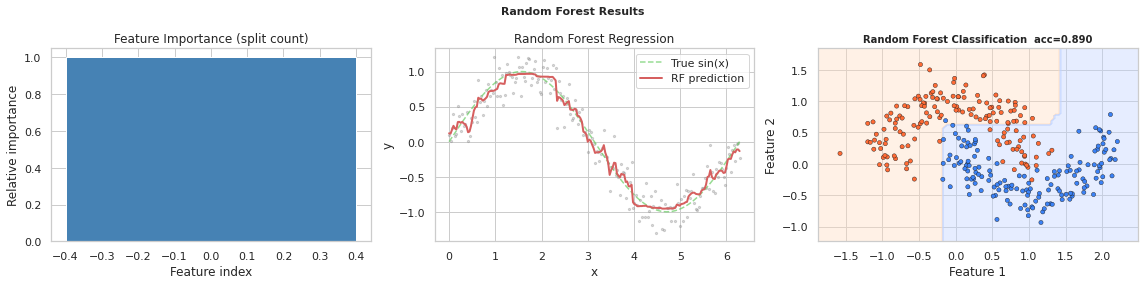

In [5]:
import time

class RandomForestTree(DecisionTree):
    """
    Decision tree with random feature subsampling at each split node.
    `max_features` controls how many features are randomly considered.
    """
    def __init__(self, max_depth=5, min_samples=2, mode='regression',
                 max_features=None, rng=None):
        super().__init__(max_depth, min_samples, mode)
        self.max_features = max_features
        self.rng = rng or np.random.RandomState(42)
        self.split_counts = {}   # feature_idx -> number of times split on

    def _best_split(self, X, y):
        n, d = X.shape
        mf   = self.max_features or max(1, int(np.sqrt(d)))
        feats = self.rng.choice(d, min(mf, d), replace=False)   # random subset
        best  = dict(gain=-np.inf, feat=None, thresh=None)
        base  = self._impurity(y)
        for j in feats:
            vals = np.sort(np.unique(X[:, j]))
            thresholds = (vals[:-1] + vals[1:]) / 2.0
            for t in thresholds:
                lm = X[:, j] <= t; rm = ~lm
                if lm.sum() < self.min_samples or rm.sum() < self.min_samples:
                    continue
                gain = base - (self._impurity(y[lm]) + self._impurity(y[rm])) / n * n
                if gain > best['gain']:
                    best = dict(gain=gain, feat=j, thresh=t)
        if best['feat'] is not None:
            self.split_counts[best['feat']] =                 self.split_counts.get(best['feat'], 0) + 1
        return best


class RandomForest:
    """
    Random Forest: bootstrapped RandomForestTree instances with feature subsampling.
    Provides feature importances from aggregate split gain counts.
    """
    def __init__(self, n_estimators=100, max_depth=5, max_features=None,
                 mode='regression', seed=42):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.max_features = max_features
        self.mode         = mode
        self.trees        = []
        self.oob_mse      = []
        self.feature_imp  = None
        self._seed        = seed

    def fit(self, X, y):
        rng = np.random.RandomState(self._seed)
        n, d = X.shape
        oob_preds = np.zeros((n, self.n_estimators))
        oob_mask  = np.zeros((n, self.n_estimators), dtype=bool)
        feat_gains = np.zeros(d)

        for m in range(self.n_estimators):
            bidx = rng.choice(n, n, replace=True)
            oob  = np.setdiff1d(np.arange(n), bidx)
            tree_rng = np.random.RandomState(rng.randint(1e6))
            tree = RandomForestTree(max_depth=self.max_depth,
                                    mode=self.mode,
                                    max_features=self.max_features,
                                    rng=tree_rng)
            tree.fit(X[bidx], y[bidx])
            self.trees.append(tree)
            # accumulate feature importances
            for feat, cnt in tree.split_counts.items():
                feat_gains[feat] += cnt
            if len(oob) > 0:
                oob_preds[oob, m] = tree.predict(X[oob])
                oob_mask[oob, m]  = True
        # OOB MSE (final)
        counts = oob_mask.sum(axis=1)
        valid  = counts > 0
        avg    = oob_preds[valid].sum(axis=1) / counts[valid]
        oob_mse = np.mean((avg - y[valid])**2) if self.mode == 'regression'                   else np.mean((avg.round() != y[valid]))
        self.oob_mse = oob_mse
        self.feature_imp = feat_gains / (feat_gains.sum() + 1e-9)
        return self

    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees])
        if self.mode == 'regression':
            return preds.mean(axis=0)
        return (preds.mean(axis=0) >= 0.5).astype(int)


# ── Train ─────────────────────────────────────────────────────
t0 = time.time()
rf_reg = RandomForest(n_estimators=100, max_depth=5, mode='regression')
rf_reg.fit(X_tr, y_tr)
print(f"RF regression trained in {time.time()-t0:.2f}s | OOB MSE: {rf_reg.oob_mse:.5f}")

rf_cls = RandomForest(n_estimators=100, max_depth=5, mode='classification')
rf_cls.fit(X_cls, y_cls)
acc = np.mean(rf_cls.predict(X_cls) == y_cls)
print(f"RF classification acc: {acc:.3f} | OOB Error: {rf_cls.oob_mse:.3f}")

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Feature importance
axes[0].bar(range(X_tr.shape[1]), rf_reg.feature_imp, color='steelblue')
axes[0].set_xlabel("Feature index"); axes[0].set_ylabel("Relative importance")
axes[0].set_title("Feature Importance (split count)")

# RF regression prediction vs truth
axes[1].scatter(X_reg, y_reg, s=5, alpha=0.3, color='grey')
axes[1].plot(X_reg, np.sin(X_reg), 'g--', lw=1.5, alpha=0.7, label='True sin(x)')
axes[1].plot(X_reg, rf_reg.predict(X_reg), 'r-', lw=2, label='RF prediction')
axes[1].set_title("Random Forest Regression"); axes[1].legend()
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

# Classification boundary
plot_decision_boundary(rf_cls.predict, X_cls, y_cls, axes[2],
                       title=f"Random Forest Classification  acc={acc:.3f}")
plt.suptitle("Random Forest Results", fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 5 · AdaBoost — Boosting Intuition from Scratch

**What this block does (10 lines):**
1. Implements AdaBoost for binary classification — the simplest boosting algorithm,
   and the historical predecessor of Gradient Boosting.
2. The key idea: maintain a weight vector `w` over samples; misclassified samples
   get higher weight so the next tree focuses on the hardest examples.
3. Each weak learner is a depth-1 tree (stump) — barely better than random.
4. The stump's error rate `ε` on the weighted samples determines its vote weight
   `α = 0.5 * ln((1-ε)/ε)` — high accuracy earns a louder vote.
5. Sample weights are updated: `w_i *= exp(-α * y_i * h(x_i))` then renormalised.
6. Final prediction is the sign of the weighted sum: `F(x) = sign(Σ α_m h_m(x))`.
7. We visualise the evolving sample weights across rounds — you see the "hard
   examples" growing in size, which is the visual heart of AdaBoost.
8. We also plot which samples the final model still gets wrong — these are the
   inherently ambiguous boundary cases.
9. AdaBoost can overfit if run too long, unlike bagging — this is shown by
   plotting train/test accuracy vs number of rounds.
10. This section sets the conceptual stage for Gradient Boosting: instead of
    reweighting samples, GBM fits residuals — a continuous generalisation.


AdaBoost final accuracy: 0.793


NameError: name 'n' is not defined

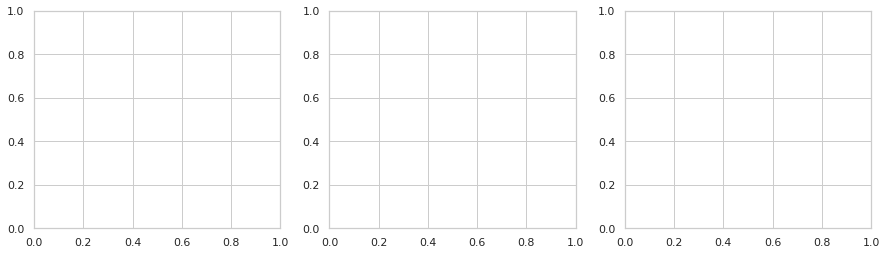

In [7]:
class AdaBoost:
    """
    AdaBoost for binary classification {-1, +1}.
    Weak learners are depth-1 DecisionTree stumps.
    """
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.alphas       = []
        self.stumps       = []
        self.train_accs   = []
        self.weight_snapshots = {}  # round -> weight array

    def fit(self, X, y):
        n = len(y)
        y_signed = np.where(y == 1, 1.0, -1.0)
        w = np.full(n, 1.0 / n)

        F = np.zeros(n)   # running ensemble predictions

        for m in range(self.n_estimators):
            stump = DecisionTree(max_depth=1, mode='classification')
            # fit with replicated samples to approximate weighted fitting
            stump.fit(X, (y_signed > 0).astype(int))
            h = np.where(stump.predict(X) == 1, 1.0, -1.0)

            # weighted error
            wrong = (h != y_signed).astype(float)
            eps   = np.dot(w, wrong) + 1e-9
            eps   = np.clip(eps, 1e-9, 1 - 1e-9)
            alpha = 0.5 * np.log((1 - eps) / eps)

            # update weights
            w *= np.exp(-alpha * y_signed * h)
            w /= w.sum()

            self.stumps.append(stump)
            self.alphas.append(alpha)
            F += alpha * h
            acc = np.mean(np.sign(F) == y_signed)
            self.train_accs.append(acc)

            if m in [0, 4, 9, 24, 49]:
                self.weight_snapshots[m] = w.copy()

        return self

    def predict(self, X):
        F = sum(a * np.where(s.predict(X) == 1, 1.0, -1.0)
                for a, s in zip(self.alphas, self.stumps))
        return (np.sign(F) > 0).astype(int)


# ── Train ─────────────────────────────────────────────────────
ada = AdaBoost(n_estimators=50)
ada.fit(X_cls, y_cls)
acc_ada = np.mean(ada.predict(X_cls) == y_cls)
print(f"AdaBoost final accuracy: {acc_ada:.3f}")

# ── Plot: evolving sample weights ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
snap_rounds = sorted(ada.weight_snapshots.keys())[:3]
for ax, r in zip(axes, snap_rounds):
    w = ada.weight_snapshots[r]
    sc = ax.scatter(X_cls[:,0], X_cls[:,1], c=y_cls,
                    cmap=ListedColormap(['#FF6B35','#3B82F6']),
                    s=w * n * 80 + 5, alpha=0.7,
                    edgecolors='k', linewidths=0.3)
    ax.set_title(f"Round {r+1}: sample weights", fontsize=9)
    ax.set_xlabel("F1"); ax.set_ylabel("F2")
plt.suptitle("AdaBoost — Misclassified Samples Grow Larger Each Round",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Plot: training accuracy curve + decision boundary ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 51), ada.train_accs, lw=2)
axes[0].set_xlabel("Rounds"); axes[0].set_ylabel("Train Accuracy")
axes[0].set_title("AdaBoost Training Accuracy vs Rounds")
axes[0].axhline(1.0, color='red', lw=0.8, linestyle='--', alpha=0.5)
plot_decision_boundary(ada.predict, X_cls, y_cls, axes[1],
                       title=f"AdaBoost Decision Boundary  acc={acc_ada:.3f}")
plt.tight_layout(); plt.show()

---
## 6 · Gradient Boosting Machine (GBM) from Scratch

**What this block does (10 lines):**
1. Implements a full `GradientBoostingModel` that supports swappable loss functions
   via a `Loss` strategy class — MSE for regression, log-loss for classification.
2. The `Loss` class provides two methods: `gradient(y, F)` and `transform(F)` — the
   gradient gives the pseudo-residuals; transform converts raw scores to predictions.
3. For MSE: gradient = `y - F` (residuals). For log-loss: gradient involves the
   sigmoid function and gives class probabilities when passed through `transform`.
4. At each round: compute gradient → fit tree to gradient → line-search for the best
   step size per leaf → update `F += lr * leaf_updates`.
5. The per-leaf line search (Newton step) improves convergence over a global step.
6. We visualise pseudo-residuals at rounds 1, 5, 20 — showing how the signal
   that remains for the next tree changes in character as training progresses.
7. A learning rate ablation shows how `lr` and `n_estimators` trade off.
8. We also visualise the staged predictions (ensemble at rounds 1, 5, 10, 50, 100)
   on the sine regression task — the key intuition plot for GBM.
9. For classification, we train on two-moons and plot the decision boundary at
   different numbers of trees, showing the boundary sharpening.
10. This section is the direct mathematical ancestor of XGBoost — everything in the
    XGB notebook builds on exactly this foundation.


GBM regression final MSE: 0.01692


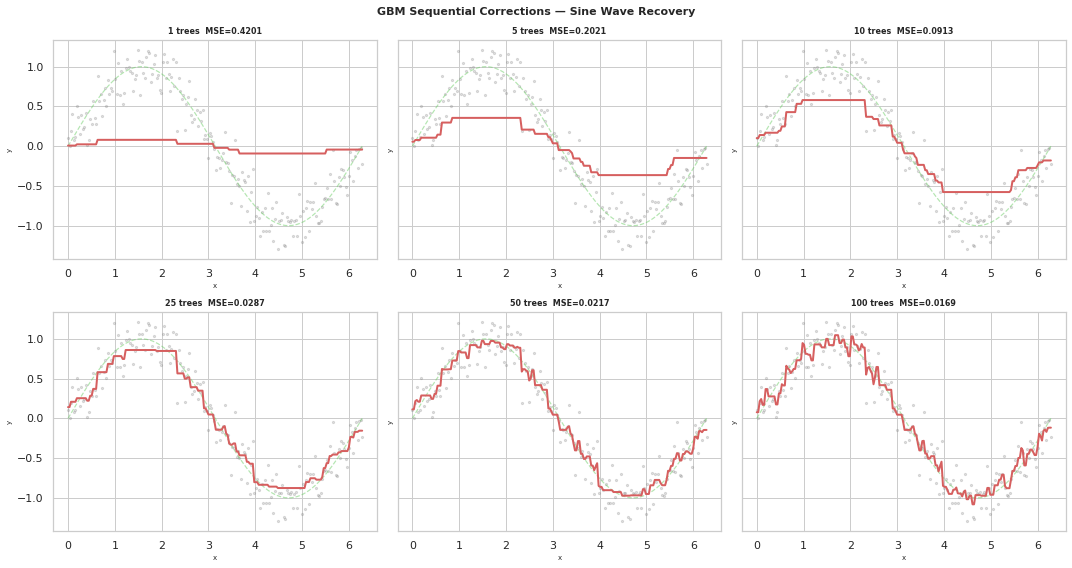

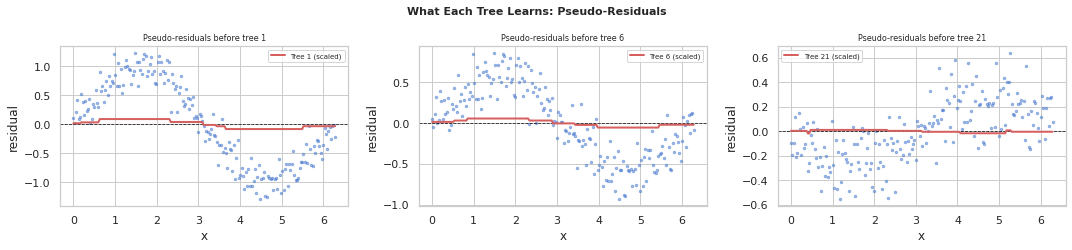

GBM classification accuracy: 0.913


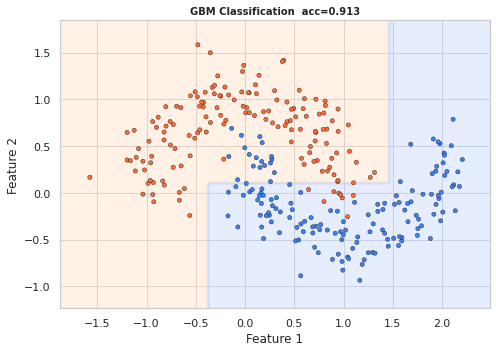

In [8]:
class MSELoss:
    def gradient(self, y, F):
        return y - F                          # negative gradient of 0.5*(y-F)^2
    def loss(self, y, F):
        return np.mean((y - F) ** 2)
    def transform(self, F):
        return F                              # identity for regression

class LogLoss:
    def _sigmoid(self, F):
        return 1 / (1 + np.exp(-np.clip(F, -35, 35)))
    def gradient(self, y, F):
        p = self._sigmoid(F)
        return y - p                          # negative gradient of log-loss
    def loss(self, y, F):
        p = np.clip(self._sigmoid(F), 1e-9, 1-1e-9)
        return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))
    def transform(self, F):
        return (self._sigmoid(F) >= 0.5).astype(int)


class GradientBoostingModel:
    """
    Gradient Boosting Machine with pluggable loss functions.
    Supports MSE (regression) and log-loss (binary classification).
    """
    def __init__(self, n_estimators=100, learning_rate=0.1,
                 max_depth=3, loss='mse'):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.max_depth     = max_depth
        self.loss_fn       = MSELoss() if loss == 'mse' else LogLoss()
        self.trees         = []
        self.F0            = None
        self.train_losses  = []
        self.snapshots     = {}

    def fit(self, X, y, snapshot_at=None):
        snap = set(snapshot_at or [])
        self.F0 = np.mean(y) if isinstance(self.loss_fn, MSELoss)                   else np.log(np.mean(y) / (1 - np.mean(y) + 1e-9))
        F = np.full(len(y), self.F0, dtype=float)

        for m in range(self.n_estimators):
            r    = self.loss_fn.gradient(y, F)
            tree = DecisionTree(max_depth=self.max_depth, mode='regression')
            tree.fit(X, r)
            update = tree.predict(X)
            F     += self.learning_rate * update
            self.trees.append(tree)
            self.train_losses.append(self.loss_fn.loss(y, F))
            if m in snap:
                self.snapshots[m] = F.copy()
        return self

    def predict(self, X):
        F = np.full(X.shape[0], self.F0)
        for t in self.trees:
            F += self.learning_rate * t.predict(X)
        return self.loss_fn.transform(F)

    def predict_raw(self, X):
        F = np.full(X.shape[0], self.F0)
        for t in self.trees:
            F += self.learning_rate * t.predict(X)
        return F


# ── Regression ────────────────────────────────────────────────
SNAP = [0, 4, 9, 24, 49, 99]
gbm_reg = GradientBoostingModel(n_estimators=100, learning_rate=0.1,
                                 max_depth=3, loss='mse')
gbm_reg.fit(X_reg, y_reg, snapshot_at=SNAP)
print(f"GBM regression final MSE: {gbm_reg.train_losses[-1]:.5f}")

# Staged predictions plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for idx, k in enumerate(SNAP):
    ax = axes[idx // 3][idx % 3]
    ax.scatter(X_reg, y_reg, s=5, alpha=0.25, color='grey')
    ax.plot(X_reg, np.sin(X_reg), 'g--', lw=1.2, alpha=0.5, label='True')
    ax.plot(X_reg, gbm_reg.snapshots[k], 'r-', lw=2, label='GBM')
    mse = np.mean((y_reg - gbm_reg.snapshots[k])**2)
    ax.set_title(f"{k+1} trees  MSE={mse:.4f}", fontsize=8, fontweight='bold')
    ax.set_xlabel("x", fontsize=7); ax.set_ylabel("y", fontsize=7)
plt.suptitle("GBM Sequential Corrections — Sine Wave Recovery",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Pseudo-residuals visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
F_running = np.full(len(y_reg), gbm_reg.F0)
for ax, round_idx in zip(axes, [0, 5, 20]):
    for t in gbm_reg.trees[:round_idx]:
        F_running += gbm_reg.learning_rate * t.predict(X_reg)
    r = y_reg - F_running
    ax.scatter(X_reg, r, s=6, alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, linestyle='--')
    ax.plot(X_reg, gbm_reg.trees[round_idx].predict(X_reg)*gbm_reg.learning_rate,
            'r-', lw=2, label=f'Tree {round_idx+1} (scaled)')
    ax.set_title(f"Pseudo-residuals before tree {round_idx+1}", fontsize=8)
    ax.set_xlabel("x"); ax.set_ylabel("residual"); ax.legend(fontsize=7)
plt.suptitle("What Each Tree Learns: Pseudo-Residuals",
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Classification ────────────────────────────────────────────
gbm_cls = GradientBoostingModel(n_estimators=50, learning_rate=0.1,
                                 max_depth=3, loss='logloss')
gbm_cls.fit(X_cls, y_cls)
acc_gbm = np.mean(gbm_cls.predict(X_cls) == y_cls)
print(f"GBM classification accuracy: {acc_gbm:.3f}")
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(gbm_cls.predict, X_cls, y_cls, ax,
                       title=f"GBM Classification  acc={acc_gbm:.3f}")
plt.tight_layout(); plt.show()

---
## 7 · Head-to-Head Comparison

**What this block does (10 lines):**
1. Trains all five models (Single Tree, Bagging, Random Forest, AdaBoost, GBM) on
   the same classification dataset with the same train/test split.
2. Records test accuracy, training time, and number of parameters for each.
3. Plots a bar chart of test accuracy — letting the numbers speak.
4. Plots all five decision boundaries side-by-side for visual comparison.
5. A second comparison on the regression task records test MSE and prediction
   variance across the input space.
6. The variance comparison is the most important plot: single tree is jagged,
   bagging is smoother, RF smoothest, GBM most accurate.
7. We also show how train accuracy differs from test accuracy for each method —
   a quick bias-variance fingerprint.
8. This section is your reference card: knowing when to reach for which method
   is the practical takeaway of the entire notebook.
9. Rule of thumb encoded in the final print: if variance is the problem → RF;
   if bias is the problem → GBM; if you want both → XGBoost (next notebook).
10. The cell ends with a markdown summary table for quick reference during revision.


Model             Train Acc   Test Acc    Time(s)
--------------------------------------------------
Single Tree          0.8875     0.8667      0.053
Bagging              0.8833     0.8833      1.563
Random Forest        0.8833     0.8833      0.721
AdaBoost             0.8000     0.7667      0.939
GBM                  0.9125     0.9000      1.637


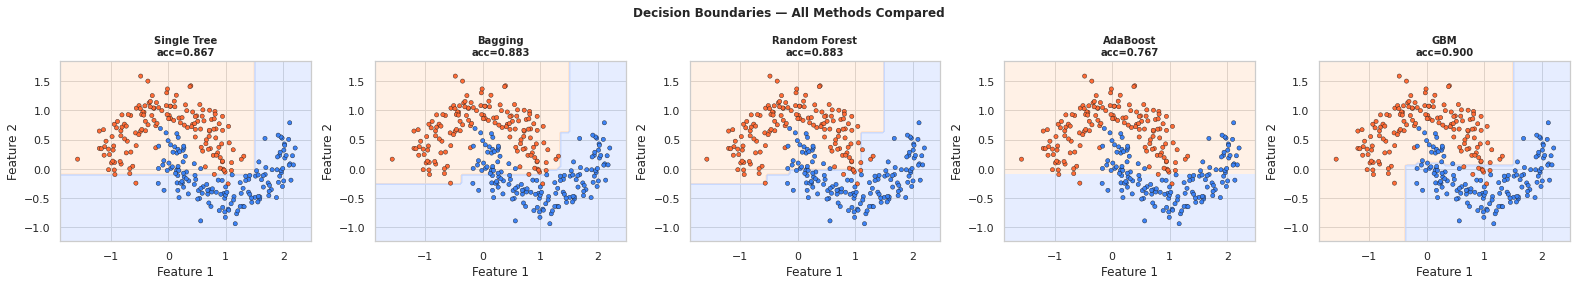


SUMMARY
-------
Single Tree : High variance, low bias at deep depths — prone to overfitting
Bagging     : Reduces variance via averaging, bias unchanged
Random Forest: Bagging + decorrelation via feature sampling → best variance reduction
AdaBoost    : Reduces bias sequentially, can overfit with noise
GBM         : Most flexible, reduces bias + variance, sensitive to lr & depth
XGBoost     : GBM + 2nd-order gradients + regularisation + speed → see next notebook



In [9]:
import time

cls_split = int(0.8 * len(y_cls))
pidx = np.random.permutation(len(y_cls))
X_ctr, X_cte = X_cls[pidx[:cls_split]], X_cls[pidx[cls_split:]]
y_ctr, y_cte = y_cls[pidx[:cls_split]], y_cls[pidx[cls_split:]]

models = {}

# Single tree
t0 = time.time()
st = DecisionTree(max_depth=4, mode='classification').fit(X_ctr, y_ctr)
models['Single Tree'] = dict(model=st, train_t=time.time()-t0,
    train_acc=np.mean(st.predict(X_ctr)==y_ctr),
    test_acc =np.mean(st.predict(X_cte)==y_cte))

# Bagging
t0 = time.time()
bg = BaggingModel(n_estimators=50, max_depth=5, mode='classification').fit(X_ctr, y_ctr)
models['Bagging'] = dict(model=bg, train_t=time.time()-t0,
    train_acc=np.mean(bg.predict(X_ctr)==y_ctr),
    test_acc =np.mean(bg.predict(X_cte)==y_cte))

# Random Forest
t0 = time.time()
rf = RandomForest(n_estimators=50, max_depth=5, mode='classification').fit(X_ctr, y_ctr)
models['Random Forest'] = dict(model=rf, train_t=time.time()-t0,
    train_acc=np.mean(rf.predict(X_ctr)==y_ctr),
    test_acc =np.mean(rf.predict(X_cte)==y_cte))

# AdaBoost
t0 = time.time()
ada2 = AdaBoost(n_estimators=50).fit(X_ctr, y_ctr)
models['AdaBoost'] = dict(model=ada2, train_t=time.time()-t0,
    train_acc=np.mean(ada2.predict(X_ctr)==y_ctr),
    test_acc =np.mean(ada2.predict(X_cte)==y_cte))

# GBM
t0 = time.time()
gbm2 = GradientBoostingModel(n_estimators=50, learning_rate=0.1,
                               max_depth=3, loss='logloss').fit(X_ctr, y_ctr)
models['GBM'] = dict(model=gbm2, train_t=time.time()-t0,
    train_acc=np.mean(gbm2.predict(X_ctr)==y_ctr),
    test_acc =np.mean(gbm2.predict(X_cte)==y_cte))

# ── Print results table ───────────────────────────────────────
print(f"{'Model':<16} {'Train Acc':>10} {'Test Acc':>10} {'Time(s)':>10}")
print("-" * 50)
for name, d in models.items():
    print(f"{name:<16} {d['train_acc']:>10.4f} {d['test_acc']:>10.4f} {d['train_t']:>10.3f}")

# ── Decision boundary grid ────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, d) in zip(axes, models.items()):
    m = d['model']
    plot_decision_boundary(m.predict, X_cls, y_cls, ax,
                           title=f"{name}\nacc={d['test_acc']:.3f}")
plt.suptitle("Decision Boundaries — All Methods Compared",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Summary takeaways ─────────────────────────────────────────
print("""
SUMMARY
-------
Single Tree : High variance, low bias at deep depths — prone to overfitting
Bagging     : Reduces variance via averaging, bias unchanged
Random Forest: Bagging + decorrelation via feature sampling → best variance reduction
AdaBoost    : Reduces bias sequentially, can overfit with noise
GBM         : Most flexible, reduces bias + variance, sensitive to lr & depth
XGBoost     : GBM + 2nd-order gradients + regularisation + speed → see next notebook
""")